<a href="https://colab.research.google.com/github/karthiksenthil742/thiranex_sales_revenue_analysis/blob/main/01_data_profiling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
import pandas as pd
import zipfile
import os

In [82]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [83]:
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [84]:
os.listdir("/content")

['.config',
 'Maven_toys',
 'drive',
 'maven_toys_file',
 'maven_toys',
 'maven_toys_analysis',
 'maven_toys_data',
 'sample_data']

In [85]:
zip_path="/content/drive/MyDrive/Maventoys/Maven+Toys.zip"
extract_path="/content/maven_toys_data"
os.makedirs(extract_path,exist_ok=True)
with zipfile.ZipFile(zip_path,"r")as zip_ref:
  zip_ref.extractall(extract_path)
print("dataset extracted successfully")

dataset extracted successfully


In [86]:
import os
os.listdir("/content/maven_toys_data")

['Maven Toys Data', '__MACOSX']

In [87]:
print(os.listdir("/content"))

['.config', 'Maven_toys', 'drive', 'maven_toys_file', 'maven_toys', 'maven_toys_analysis', 'maven_toys_data', 'sample_data']


In [88]:
import os
data_path="/content/maven_toys_data/Maven Toys Data"
print(os.listdir(data_path))


['inventory.csv', 'stores.csv', 'calendar.csv', 'sales.csv', 'products.csv', 'data_dictionary.csv']


In [89]:
import pandas as pd
import os
data_path="/content/maven_toys_data/Maven Toys Data"
sales=pd.read_csv(os.path.join(data_path,"sales.csv"))
inventory=pd.read_csv(os.path.join(data_path,"inventory.csv"))
stores=pd.read_csv(os.path.join(data_path,"stores.csv"))
products=pd.read_csv(os.path.join(data_path,"products.csv"))
data_dictionary=pd.read_csv(os.path.join(data_path,"data_dictionary.csv"))
calendar=pd.read_csv(os.path.join(data_path,"calendar.csv"))
print("Sales:",sales.shape)
print("Inventory:",inventory.shape)
print("Stores:",stores.shape)
print("Products:",products.shape)
print("DataDictionary:",data_dictionary.shape)
print("calendar:",calendar.shape)

Sales: (829262, 5)
Inventory: (1593, 3)
Stores: (50, 5)
Products: (35, 5)
DataDictionary: (19, 3)
calendar: (638, 1)


In [90]:
tables={"sales":sales,"inventory":inventory,"stores":stores,"products":products,"data_dictionary":data_dictionary,"calendar":calendar}
for name,df in tables.items():
  print(f"\n{'='*50}")
  print(name)
  print(f"{'='*50}")
  print("shape:",df.shape)
  print("columns:",df.columns.tolist())
  print("\nData Types:")
  print(df.dtypes)


sales
shape: (829262, 5)
columns: ['Sale_ID', 'Date', 'Store_ID', 'Product_ID', 'Units']

Data Types:
Sale_ID        int64
Date          object
Store_ID       int64
Product_ID     int64
Units          int64
dtype: object

inventory
shape: (1593, 3)
columns: ['Store_ID', 'Product_ID', 'Stock_On_Hand']

Data Types:
Store_ID         int64
Product_ID       int64
Stock_On_Hand    int64
dtype: object

stores
shape: (50, 5)
columns: ['Store_ID', 'Store_Name', 'Store_City', 'Store_Location', 'Store_Open_Date']

Data Types:
Store_ID            int64
Store_Name         object
Store_City         object
Store_Location     object
Store_Open_Date    object
dtype: object

products
shape: (35, 5)
columns: ['Product_ID', 'Product_Name', 'Product_Category', 'Product_Cost', 'Product_Price']

Data Types:
Product_ID           int64
Product_Name        object
Product_Category    object
Product_Cost        object
Product_Price       object
dtype: object

data_dictionary
shape: (19, 3)
columns: ['Table', 'Fi

In [91]:
display(data_dictionary)

,Table,Field,Description
0,Products,Product_ID,Product ID
1,Products,Product_Name,Product name
2,Products,Product_Category,Product Category
3,Products,Product_Cost,Product cost ($USD)
4,Products,Product_Price,Product retail price ($USD)
5,Inventory,Store_ID,Store ID
6,Inventory,Product_ID,Product ID
7,Inventory,Stock_On_Hand,Stock quantity of the product in the store (in...
8,Stores,Store_ID,Store ID
9,Stores,Store_Name,Store name


In [92]:
for name, df in tables.items():
    print(f"\n{'='*40}")
    print(name)
    print(f"{'='*40}")
    print(df.isnull().sum())



sales
Sale_ID       0
Date          0
Store_ID      0
Product_ID    0
Units         0
dtype: int64

inventory
Store_ID         0
Product_ID       0
Stock_On_Hand    0
dtype: int64

stores
Store_ID           0
Store_Name         0
Store_City         0
Store_Location     0
Store_Open_Date    0
dtype: int64

products
Product_ID          0
Product_Name        0
Product_Category    0
Product_Cost        0
Product_Price       0
dtype: int64

data_dictionary
Table          0
Field          0
Description    0
dtype: int64

calendar
Date    0
dtype: int64


In [93]:
for name, df in tables.items():
    missing = df.isnull().sum().sum()
    print(f"{name}: {missing} missing values")


sales: 0 missing values
inventory: 0 missing values
stores: 0 missing values
products: 0 missing values
data_dictionary: 0 missing values
calendar: 0 missing values


In [94]:
for name, df in tables.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")


sales: 0 duplicate rows
inventory: 0 duplicate rows
stores: 0 duplicate rows
products: 0 duplicate rows
data_dictionary: 0 duplicate rows
calendar: 0 duplicate rows


In [95]:
print("Duplicate Sale_IDs:", sales["Sale_ID"].duplicated().sum())
print("Duplicate Product_IDs:", products["Product_ID"].duplicated().sum())
print("Duplicate Store_IDs:", stores["Store_ID"].duplicated().sum())


Duplicate Sale_IDs: 0
Duplicate Product_IDs: 0
Duplicate Store_IDs: 0


In [96]:
sales_products = set(sales["Product_ID"])
master_products = set(products["Product_ID"])

invalid_products = sales_products - master_products

print("Unmatched Product IDs:", len(invalid_products))
print("IDs:", sorted(invalid_products))


Unmatched Product IDs: 0
IDs: []


In [97]:
sales_stores = set(sales["Store_ID"])
master_stores = set(stores["Store_ID"])

invalid_stores = sales_stores - master_stores

print("Unmatched Store IDs:", len(invalid_stores))
print("IDs:", sorted(invalid_stores))


Unmatched Store IDs: 0
IDs: []


In [98]:
print(inventory.columns.tolist())

['Store_ID', 'Product_ID', 'Stock_On_Hand']


In [99]:
invalid_inventory_products=set(inventory["Product_ID"])-set(products["Product_ID"])
invalid_inventory_stores=set(inventory["Store_ID"])-set(stores["Store_ID"])
print("Unmatched inventory Product IDs:",len(invalid_inventory_products))
print("unmatched inventory store IDs:",len(invalid_inventory_stores))

Unmatched inventory Product IDs: 0
unmatched inventory store IDs: 0


In [100]:
print("duplicate store-product combinations:",inventory.duplicated(subset=["Store_ID","Product_ID"]).sum())

duplicate store-product combinations: 0


In [101]:
print("PRODUCT COST:")
print(products["Product_Cost"].head(10).tolist())

print("\nPRODUCT PRICE:")
print(products["Product_Price"].head(10).tolist())

print("\nSALES DATE:")
print(sales["Date"].head(5).tolist())

print("\nSTORE OPEN DATE:")
print(stores["Store_Open_Date"].head(5).tolist())

print("\nCALENDAR DATE:")
print(calendar["Date"].head(5).tolist())


PRODUCT COST:
['$9.99 ', '$9.99 ', '$1.99 ', '$9.99 ', '$7.99 ', '$6.99 ', '$11.99 ', '$3.99 ', '$9.99 ', '$10.99 ']

PRODUCT PRICE:
['$15.99 ', '$12.99 ', '$3.99 ', '$12.99 ', '$9.99 ', '$14.99 ', '$15.99 ', '$6.99 ', '$10.99 ', '$14.99 ']

SALES DATE:
['2022-01-01', '2022-01-01', '2022-01-01', '2022-01-01', '2022-01-01']

STORE OPEN DATE:
['1992-09-18', '1995-04-27', '1999-12-27', '2000-01-01', '2001-05-31']

CALENDAR DATE:
['1/1/2022', '1/2/2022', '1/3/2022', '1/4/2022', '1/5/2022']


In [102]:
sales_clean=sales.copy()
inventory_clean=inventory.copy()
stores_clean=stores.copy()
products_clean=products.copy()
calendar_clean=calendar.copy()

In [103]:
products_clean["Products_cost"]=(products_clean["Product_Cost"].str.replace("$","",regex=False).str.strip().astype(float))
products_clean["Product_price"]=(products_clean["Product_Price"].str.replace("$","",regex=False).str.strip().astype(float))


In [104]:
print(products_clean[["Product_Cost","Product_price"]].head())
print(products_clean[["Product_Cost","Product_price"]].dtypes)

  Product_Cost  Product_price
0       $9.99           15.99
1       $9.99           12.99
2       $1.99            3.99
3       $9.99           12.99
4       $7.99            9.99
Product_Cost      object
Product_price    float64
dtype: object


In [105]:
print(products_clean[["Product_Cost","Product_price"]].head(10))
print("\nData types:")
print(products_clean[["Product_Cost","Product_price"]].dtypes)

  Product_Cost  Product_price
0       $9.99           15.99
1       $9.99           12.99
2       $1.99            3.99
3       $9.99           12.99
4       $7.99            9.99
5       $6.99           14.99
6      $11.99           15.99
7       $3.99            6.99
8       $9.99           10.99
9      $10.99           14.99

Data types:
Product_Cost      object
Product_price    float64
dtype: object


In [106]:
print(products_clean["Product_Cost"].head(10))
print(products_clean["Product_price"].dtype)

0     $9.99 
1     $9.99 
2     $1.99 
3     $9.99 
4     $7.99 
5     $6.99 
6    $11.99 
7     $3.99 
8     $9.99 
9    $10.99 
Name: Product_Cost, dtype: object
float64


In [107]:
print(products_clean["Product_Cost"].map(type).value_counts())

Product_Cost
<class 'str'>    35
Name: count, dtype: int64


In [108]:
products_clean["Product_Cost"]=(products_clean["Product_Cost"].astype(str).str.replace("$","",regex=False).str.strip().astype(float))

In [109]:
print(products_clean["Product_Cost"].head(10))
print("\nData type:")
print(products_clean["Product_Cost"].dtype)

0     9.99
1     9.99
2     1.99
3     9.99
4     7.99
5     6.99
6    11.99
7     3.99
8     9.99
9    10.99
Name: Product_Cost, dtype: float64

Data type:
float64


In [110]:
print(products_clean[["Product_Cost","Product_Price"]].dtypes)

Product_Cost     float64
Product_Price     object
dtype: object


In [111]:
products_clean["Product_Cost"] = products["Product_Cost"].copy()
products_clean["Product_Price"] = products["Product_Price"].copy()


In [112]:
for col in ["Product_Cost", "Product_Price"]:
    products_clean[col] = (
        products_clean[col]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.strip()
        .astype(float)
    )


In [113]:
print(products_clean[["Product_Cost", "Product_Price"]].dtypes)

Product_Cost     float64
Product_Price    float64
dtype: object


In [114]:
display(products_clean[["Product_Cost", "Product_Price"]].head(10))

,Product_Cost,Product_Price
0,9.99,15.99
1,9.99,12.99
2,1.99,3.99
3,9.99,12.99
4,7.99,9.99
5,6.99,14.99
6,11.99,15.99
7,3.99,6.99
8,9.99,10.99
9,10.99,14.99


In [115]:
sales_clean["Date"] = pd.to_datetime(sales_clean["Date"])
stores_clean["Store_Open_Date"] = pd.to_datetime(stores_clean["Store_Open_Date"])
calendar_clean["Date"] = pd.to_datetime(calendar_clean["Date"])

print("Sales Date:", sales_clean["Date"].dtype)
print("Store Open Date:", stores_clean["Store_Open_Date"].dtype)
print("Calendar Date:", calendar_clean["Date"].dtype)


Sales Date: datetime64[ns]
Store Open Date: datetime64[ns]
Calendar Date: datetime64[ns]


In [116]:
print("Sales:", sales_clean["Date"].min(), "→", sales_clean["Date"].max())
print("Calendar:", calendar_clean["Date"].min(), "→", calendar_clean["Date"].max())


Sales: 2022-01-01 00:00:00 → 2023-09-30 00:00:00
Calendar: 2022-01-01 00:00:00 → 2023-09-30 00:00:00


In [117]:
sales_analysis = sales_clean.merge(
    products_clean,
    left_on="Product_ID",
    right_on="Product_ID",
    how="left"
)

print("Shape:", sales_analysis.shape)
display(sales_analysis.head())



Shape: (829262, 11)


,Sale_ID,Date,Store_ID,Product_ID,Units,Product_Name,Product_Category,Product_Cost,Product_Price,Products_cost,Product_price
0,1,2022-01-01,24,4,1,Chutes & Ladders,Games,9.99,12.99,9.99,12.99
1,2,2022-01-01,28,1,1,Action Figure,Toys,9.99,15.99,9.99,15.99
2,3,2022-01-01,6,8,1,Deck Of Cards,Games,3.99,6.99,3.99,6.99
3,4,2022-01-01,48,7,1,Dart Gun,Sports & Outdoors,11.99,15.99,11.99,15.99
4,5,2022-01-01,44,18,1,Lego Bricks,Toys,34.99,39.99,34.99,39.99


In [118]:
sales_analysis = sales_analysis.merge(
    stores_clean,
    on="Store_ID",
    how="left"
)

print("Shape:", sales_analysis.shape)
display(sales_analysis.head())


Shape: (829262, 15)


,Sale_ID,Date,Store_ID,Product_ID,Units,Product_Name,Product_Category,Product_Cost,Product_Price,Products_cost,Product_price,Store_Name,Store_City,Store_Location,Store_Open_Date
0,1,2022-01-01,24,4,1,Chutes & Ladders,Games,9.99,12.99,9.99,12.99,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31
1,2,2022-01-01,28,1,1,Action Figure,Toys,9.99,15.99,9.99,15.99,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01
2,3,2022-01-01,6,8,1,Deck Of Cards,Games,3.99,6.99,3.99,6.99,Maven Toys Mexicali 1,Mexicali,Commercial,2003-12-13
3,4,2022-01-01,48,7,1,Dart Gun,Sports & Outdoors,11.99,15.99,11.99,15.99,Maven Toys Saltillo 2,Saltillo,Commercial,2016-03-23
4,5,2022-01-01,44,18,1,Lego Bricks,Toys,34.99,39.99,34.99,39.99,Maven Toys Puebla 3,Puebla,Residential,2014-12-27


In [119]:
sales_analysis["Revenue"] = (
    sales_analysis["Units"] *
    sales_analysis["Product_Price"]
)

sales_analysis["Cost"] = (
    sales_analysis["Units"] *
    sales_analysis["Product_Cost"]
)

sales_analysis["Profit"] = (
    sales_analysis["Revenue"] -
    sales_analysis["Cost"]
)

sales_analysis["Profit_Margin"] = (
    sales_analysis["Profit"] /
    sales_analysis["Revenue"]
)


In [120]:
display(
    sales_analysis[
        [
            "Product_Name",
            "Units",
            "Product_Cost",
            "Product_Price",
            "Revenue",
            "Cost",
            "Profit",
            "Profit_Margin"
        ]
    ].head(10)
)


,Product_Name,Units,Product_Cost,Product_Price,Revenue,Cost,Profit,Profit_Margin
0,Chutes & Ladders,1,9.99,12.99,12.99,9.99,3.0,0.230947
1,Action Figure,1,9.99,15.99,15.99,9.99,6.0,0.375235
2,Deck Of Cards,1,3.99,6.99,6.99,3.99,3.0,0.429185
3,Dart Gun,1,11.99,15.99,15.99,11.99,4.0,0.250156
4,Lego Bricks,1,34.99,39.99,39.99,34.99,5.0,0.125031
5,Splash Balls,1,7.99,8.99,8.99,7.99,1.0,0.111235
6,Dart Gun,1,11.99,15.99,15.99,11.99,4.0,0.250156
7,Animal Figures,1,9.99,12.99,12.99,9.99,3.0,0.230947
8,Mini Ping Pong Set,1,6.99,9.99,9.99,6.99,3.0,0.300300
9,Deck Of Cards,1,3.99,6.99,6.99,3.99,3.0,0.429185


In [121]:
# Overall business KPIs

total_units = sales_analysis["Units"].sum()
total_revenue = sales_analysis["Revenue"].sum()
total_cost = sales_analysis["Cost"].sum()
total_profit = sales_analysis["Profit"].sum()
profit_margin = total_profit / total_revenue

print("TOTAL UNITS SOLD :", f"{total_units:,.0f}")
print("TOTAL REVENUE    :", f"${total_revenue:,.2f}")
print("TOTAL COST       :", f"${total_cost:,.2f}")
print("TOTAL PROFIT     :", f"${total_profit:,.2f}")
print("PROFIT MARGIN    :", f"{profit_margin:.2%}")


TOTAL UNITS SOLD : 1,090,565
TOTAL REVENUE    : $14,444,572.35
TOTAL COST       : $10,430,543.35
TOTAL PROFIT     : $4,014,029.00
PROFIT MARGIN    : 27.79%


In [122]:
product_performance = (
    sales_analysis
    .groupby(
        ["Product_ID", "Product_Name", "Product_Category"],
        as_index=False
    )
    .agg(
        Units_Sold=("Units", "sum"),
        Revenue=("Revenue", "sum"),
        Cost=("Cost", "sum"),
        Profit=("Profit", "sum")
    )
)

product_performance["Profit_Margin"] = (
    product_performance["Profit"] /
    product_performance["Revenue"]
)

product_performance = product_performance.sort_values(
    "Revenue",
    ascending=False
)

display(product_performance.head(10))


,Product_ID,Product_Name,Product_Category,Units_Sold,Revenue,Cost,Profit,Profit_Margin
17,18,Lego Bricks,Toys,59737,2388882.63,2090197.63,298685.0,0.125031
5,6,Colorbuds,Electronics,104368,1564476.32,729532.32,834944.0,0.533689
18,19,Magic Sand,Art & Crafts,60598,968962.02,847766.02,121196.0,0.125078
0,1,Action Figure,Toys,57958,926748.42,579000.42,347748.0,0.375235
29,30,Rubik's Cube,Games,45672,912983.28,821639.28,91344.0,0.100050
7,8,Deck Of Cards,Games,84034,587397.66,335295.66,252102.0,0.429185
30,31,Splash Balls,Sports & Outdoors,60248,541629.52,481381.52,60248.0,0.111235
23,24,Nerf Gun,Sports & Outdoors,26543,530594.57,397879.57,132715.0,0.250125
1,2,Animal Figures,Toys,39089,507766.11,390499.11,117267.0,0.230947
6,7,Dart Gun,Sports & Outdoors,31588,505092.12,378740.12,126352.0,0.250156


In [123]:
category_performance = (
    sales_analysis
    .groupby("Product_Category", as_index=False)
    .agg(
        Units_Sold=("Units", "sum"),
        Revenue=("Revenue", "sum"),
        Cost=("Cost", "sum"),
        Profit=("Profit", "sum")
    )
)

category_performance["Profit_Margin"] = (
    category_performance["Profit"] /
    category_performance["Revenue"]
)

category_performance = category_performance.sort_values(
    "Revenue",
    ascending=False
)

display(category_performance)


,Product_Category,Units_Sold,Revenue,Cost,Profit,Profit_Margin
4,Toys,267200,5093241.00,4013714.00,1079527.0,0.211953
0,Art & Crafts,325574,2705364.26,1952010.26,753354.0,0.278467
1,Electronics,134075,2246771.25,1245334.25,1001437.0,0.445723
2,Games,194673,2226836.27,1552843.27,673993.0,0.302668
3,Sports & Outdoors,169043,2172359.57,1666641.57,505718.0,0.232797


In [124]:
monthly_performance = (
    sales_analysis
    .groupby(
        sales_analysis["Date"].dt.to_period("M")
    )
    .agg(
        Units_Sold=("Units", "sum"),
        Revenue=("Revenue", "sum"),
        Cost=("Cost", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

monthly_performance["Date"] = (
    monthly_performance["Date"].dt.to_timestamp()
)

monthly_performance["Profit_Margin"] = (
    monthly_performance["Profit"] /
    monthly_performance["Revenue"]
)

display(monthly_performance)


,Date,Units_Sold,Revenue,Cost,Profit,Profit_Margin
0,2022-01-01,38009,542554.91,375428.91,167126.0,0.308035
1,2022-02-01,36935,541351.65,379490.65,161861.0,0.298994
2,2022-03-01,39981,589485.19,415493.19,173992.0,0.295159
3,2022-04-01,47102,681072.98,490973.98,190099.0,0.279117
4,2022-05-01,46910,672369.90,485475.90,186894.0,0.277963
5,2022-06-01,47178,661980.22,472165.22,189815.0,0.286738
6,2022-07-01,46177,556034.23,379112.23,176922.0,0.318185
7,2022-08-01,39927,489422.73,330491.73,158931.0,0.324732
8,2022-09-01,42196,585844.04,419447.04,166397.0,0.284030
9,2022-10-01,47861,623874.39,445075.39,178799.0,0.286595


In [125]:
store_performance = (
    sales_analysis
    .groupby(
        ["Store_ID", "Store_Name", "Store_City", "Store_Location"],
        as_index=False
    )
    .agg(
        Units_Sold=("Units", "sum"),
        Revenue=("Revenue", "sum"),
        Cost=("Cost", "sum"),
        Profit=("Profit", "sum")
    )
)

store_performance["Profit_Margin"] = (
    store_performance["Profit"] /
    store_performance["Revenue"]
)

store_performance = store_performance.sort_values(
    "Revenue",
    ascending=False
)

display(store_performance.head(10))


,Store_ID,Store_Name,Store_City,Store_Location,Units_Sold,Revenue,Cost,Profit,Profit_Margin
30,31,Maven Toys Ciudad de Mexico 2,Cuidad de Mexico,Airport,42757,554553.43,384697.43,169856.0,0.306293
29,30,Maven Toys Guadalajara 3,Guadalajara,Airport,31609,449354.91,327783.91,121571.0,0.270546
8,9,Maven Toys Ciudad de Mexico 1,Cuidad de Mexico,Downtown,33479,433556.21,322260.21,111296.0,0.256705
16,17,Maven Toys Toluca 1,Toluca,Downtown,32668,411157.32,306545.32,104612.0,0.254433
6,7,Maven Toys Monterrey 2,Monterrey,Downtown,28318,372998.82,266215.82,106783.0,0.286282
45,46,Maven Toys Guadalajara 4,Guadalajara,Downtown,24136,348466.64,246288.64,102178.0,0.293222
41,42,Maven Toys Hermosillo 3,Hermosillo,Commercial,23236,344846.64,246021.64,98825.0,0.286577
38,39,Maven Toys Xalapa 2,Xalapa,Downtown,25296,344307.04,255670.04,88637.0,0.257436
36,37,Maven Toys Ciudad de Mexico 3,Cuidad de Mexico,Residential,26634,337424.66,243403.66,94021.0,0.278643
3,4,Maven Toys Saltillo 1,Saltillo,Downtown,24010,330408.90,236156.90,94252.0,0.285259


In [126]:
output_path = "/content/maven_toys_analysis"

os.makedirs(output_path, exist_ok=True)

product_performance.to_csv(
    f"{output_path}/product_performance.csv",
    index=False
)

category_performance.to_csv(
    f"{output_path}/category_performance.csv",
    index=False
)

monthly_performance.to_csv(
    f"{output_path}/monthly_performance.csv",
    index=False
)

store_performance.to_csv(
    f"{output_path}/store_performance.csv",
    index=False
)

products_clean.to_csv(
    f"{output_path}/products_clean.csv",
    index=False
)

sales_clean.to_csv(
    f"{output_path}/sales_clean.csv",
    index=False
)

print("Analysis files saved successfully!")
print(os.listdir(output_path))


Analysis files saved successfully!
['product_performance.csv', 'products_clean.csv', 'monthly_performance.csv', 'store_performance.csv', 'category_performance.csv', 'sales_clean.csv']


In [127]:
output_path = "/content/maven_toys_analysis"
os.makedirs(output_path, exist_ok=True)

product_performance.to_csv(
    f"{output_path}/product_performance.csv", index=False
)

category_performance.to_csv(
    f"{output_path}/category_performance.csv", index=False
)

monthly_performance.to_csv(
    f"{output_path}/monthly_performance.csv", index=False
)

store_performance.to_csv(
    f"{output_path}/store_performance.csv", index=False
)

products_clean.to_csv(
    f"{output_path}/products_clean.csv", index=False
)

sales_clean.to_csv(
    f"{output_path}/sales_clean.csv", index=False
)

print("Analysis files saved!")
print(os.listdir(output_path))



Analysis files saved!
['product_performance.csv', 'products_clean.csv', 'monthly_performance.csv', 'store_performance.csv', 'category_performance.csv', 'sales_clean.csv']


In [128]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Units Sold",
        "Total Revenue",
        "Total Cost",
        "Total Profit",
        "Profit Margin"
    ],
    "Value": [
        total_units,
        total_revenue,
        total_cost,
        total_profit,
        profit_margin
    ]
})

display(kpi_summary)


,Metric,Value
0,Total Units Sold,1.090565e+06
1,Total Revenue,1.444457e+07
2,Total Cost,1.043054e+07
3,Total Profit,4.014029e+06
4,Profit Margin,2.778919e-01


In [129]:
top_10_products = product_performance.head(10)

bottom_10_products = (
    product_performance
    .sort_values("Revenue", ascending=True)
    .head(10)
)

print("🏆 TOP 10 PRODUCTS BY REVENUE")
display(top_10_products)

print("📉 BOTTOM 10 PRODUCTS BY REVENUE")
display(bottom_10_products)


🏆 TOP 10 PRODUCTS BY REVENUE


,Product_ID,Product_Name,Product_Category,Units_Sold,Revenue,Cost,Profit,Profit_Margin
17,18,Lego Bricks,Toys,59737,2388882.63,2090197.63,298685.0,0.125031
5,6,Colorbuds,Electronics,104368,1564476.32,729532.32,834944.0,0.533689
18,19,Magic Sand,Art & Crafts,60598,968962.02,847766.02,121196.0,0.125078
0,1,Action Figure,Toys,57958,926748.42,579000.42,347748.0,0.375235
29,30,Rubik's Cube,Games,45672,912983.28,821639.28,91344.0,0.100050
7,8,Deck Of Cards,Games,84034,587397.66,335295.66,252102.0,0.429185
30,31,Splash Balls,Sports & Outdoors,60248,541629.52,481381.52,60248.0,0.111235
23,24,Nerf Gun,Sports & Outdoors,26543,530594.57,397879.57,132715.0,0.250125
1,2,Animal Figures,Toys,39089,507766.11,390499.11,117267.0,0.230947
6,7,Dart Gun,Sports & Outdoors,31588,505092.12,378740.12,126352.0,0.250156


📉 BOTTOM 10 PRODUCTS BY REVENUE


,Product_ID,Product_Name,Product_Category,Units_Sold,Revenue,Cost,Profit,Profit_Margin
34,35,Uno Card Game,Games,2710,21652.90,10812.90,10840.0,0.500626
4,5,Classic Dominoes,Games,4471,44665.29,35723.29,8942.0,0.200200
27,28,Playfoam,Art & Crafts,4158,45696.42,16590.42,29106.0,0.636943
3,4,Chutes & Ladders,Games,3829,49738.71,38251.71,11487.0,0.230947
19,20,Mini Basketball Hoop,Sports & Outdoors,2647,66148.53,23796.53,42352.0,0.640256
21,22,Monopoly,Games,3385,67666.15,47356.15,20310.0,0.300150
32,33,Teddy Bear,Toys,6416,83343.84,70511.84,12832.0,0.153965
22,23,Mr. Potatohead,Toys,8605,85963.95,42938.95,43025.0,0.500501
11,12,Foam Disk Launcher,Sports & Outdoors,7620,91363.80,68503.80,22860.0,0.250209
31,32,Supersoaker Water Gun,Sports & Outdoors,6793,101827.07,81448.07,20379.0,0.200133


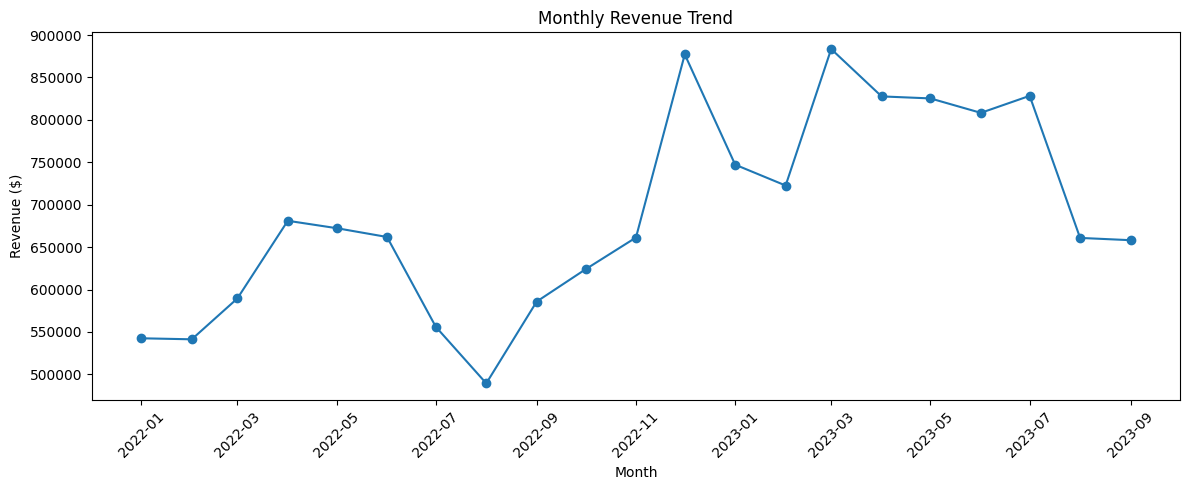

In [130]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(
    monthly_performance["Date"],
    monthly_performance["Revenue"],
    marker="o"
)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


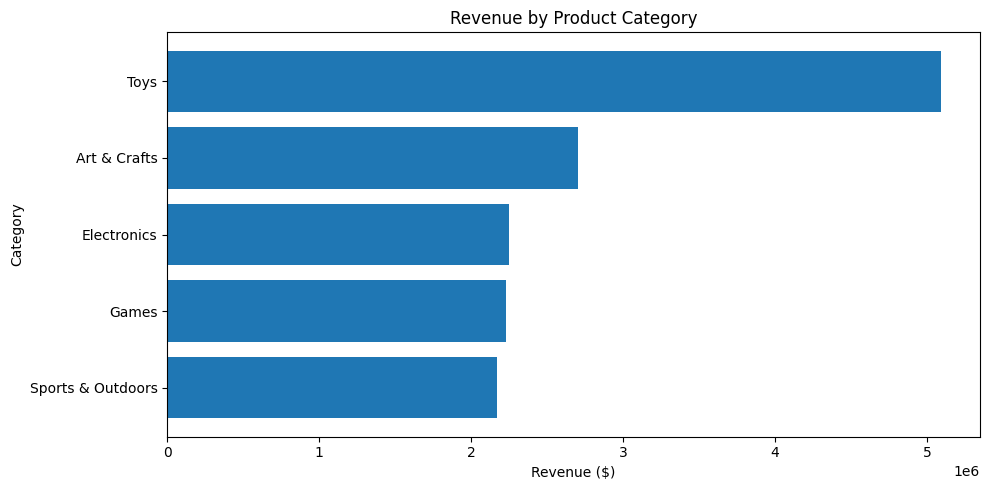

In [131]:
category_plot = category_performance.sort_values(
    "Revenue", ascending=True
)

plt.figure(figsize=(10,5))
plt.barh(
    category_plot["Product_Category"],
    category_plot["Revenue"]
)
plt.title("Revenue by Product Category")
plt.xlabel("Revenue ($)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


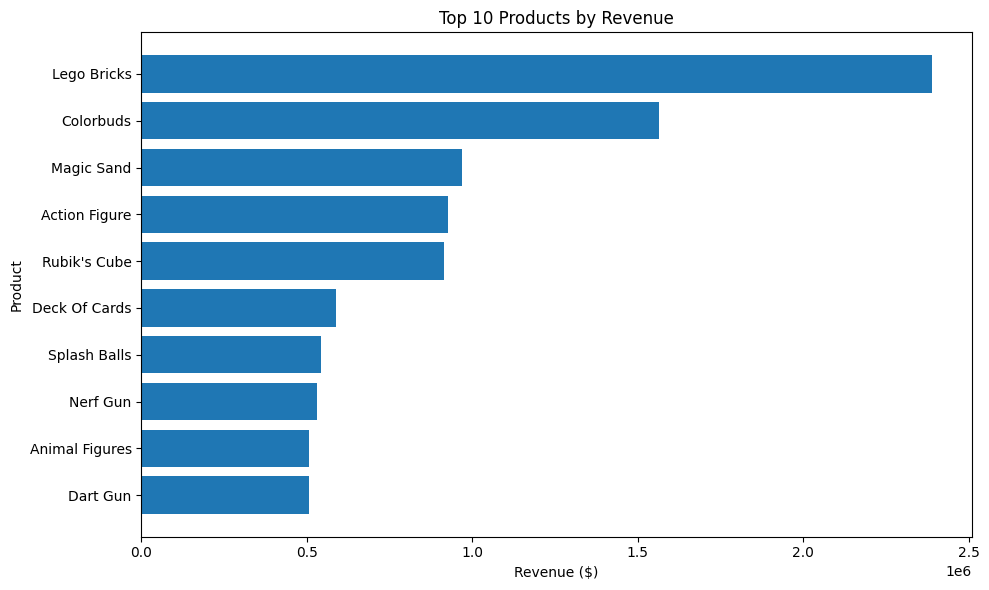

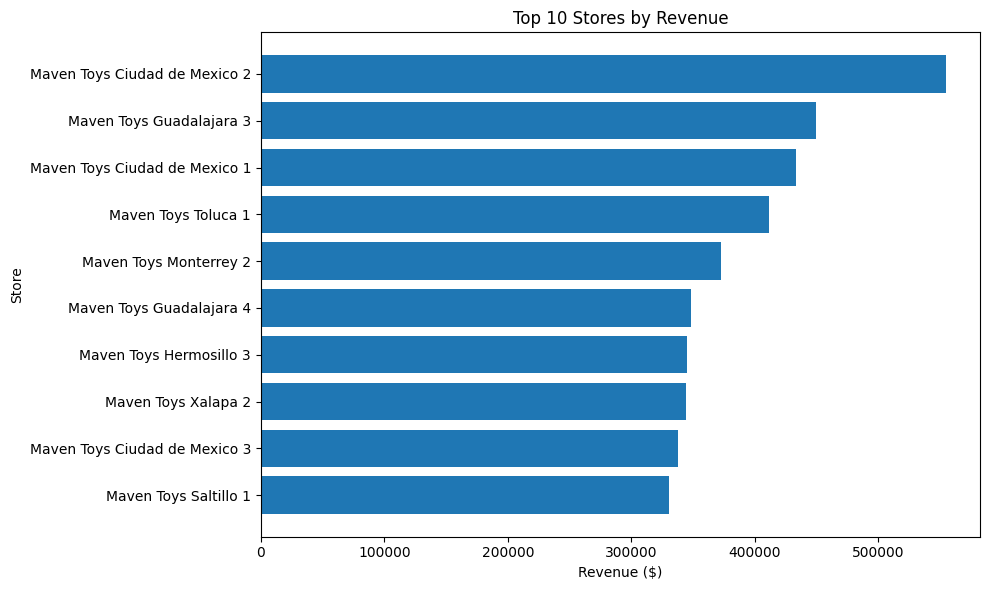

In [132]:
top_plot = product_performance.head(10).sort_values(
    "Revenue", ascending=True
)

plt.figure(figsize=(10,6))
plt.barh(
    top_plot["Product_Name"],
    top_plot["Revenue"]
)
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


store_plot = store_performance.head(10).sort_values(
    "Revenue", ascending=True
)

plt.figure(figsize=(10,6))
plt.barh(
    store_plot["Store_Name"],
    store_plot["Revenue"]
)
plt.title("Top 10 Stores by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Store")
plt.tight_layout()
plt.show()
